(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   2.,   0.,
          0.,   1.,   2.,   0.,   3.,   0.,   5.,   1.,   2.,   4.,   5.,
          9.,  15.,  16.,  19.,  42.,  41.,  84., 114., 175., 179., 184.,
        151., 111.,  94.,  74.,  54.,  45.,  39.,  30.,  25.,  25.,  13.,
         11.,  15.,   6.,   6.,   5.,   4.,   4.,   6.,   4.,   5.,   5.,
          2.,   1.,   2.,   1.,   1.,   0.,   0.,   1.,   3.,   0.,   0.,
          0.,   2.,   2.,   1.,   7.,  25.,  28.,  10.,   7.,   0.,   0.,
          2.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   1.]),
 array([-8.79121634, -8.61959538, -8.44797442, -8.27635346, -8.10473249,
        -7.93311153, -7.76149057, -7.58986961, -7.41824865, -7.24662769,
        -7.07500672, -6.90338576, -6.7317648 , -6.56014384, -6.38852288,
        -6.21690192, -6.04528095, -5.87365999, -5.7

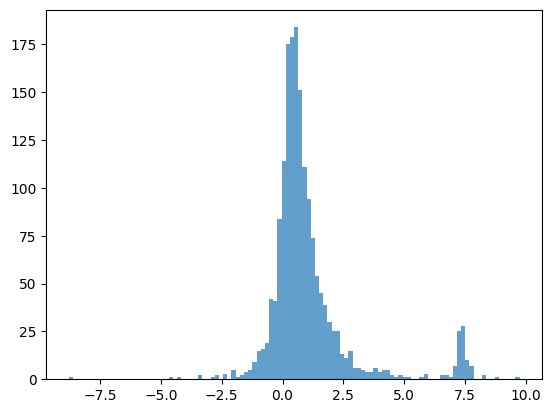

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the CSV file
file_path = "data.csv"  # Update the file path

df = pd.read_csv(file_path).dropna()

# Display the cleaned DataFrame
#print(df)

Zero_points_lambda = {"Gia_g":2.5E-9, "Gia_Gpg":4.11E-9, "Gia_Grp":1.24E-9}

plt.hist(df["parallax"], bins='auto', alpha=0.7)

[[ 0.40071007 -0.0435196   0.1556135  ...  7.16417239 -1.70121402
   0.33828824]
 [ 0.40071007 -0.0435196   0.1556135  ...  7.16417239 -1.70121402
   0.33828824]
 [ 0.40071007 -0.0435196   0.1556135  ...  7.16417239 -1.70121402
   0.33828824]
 ...
 [ 0.40071007 -0.0435196   0.1556135  ...  7.16417239 -1.70121402
   0.33828824]
 [ 0.40071007 -0.0435196   0.1556135  ...  7.16417239 -1.70121402
   0.33828824]
 [ 0.40071007 -0.0435196   0.1556135  ...  7.16417239 -1.70121402
   0.33828824]]


notebook-cell.py: RuntimeWarning: overflow encountered in exp
  return (1/L**3)*d**2*np.exp(-d/L)


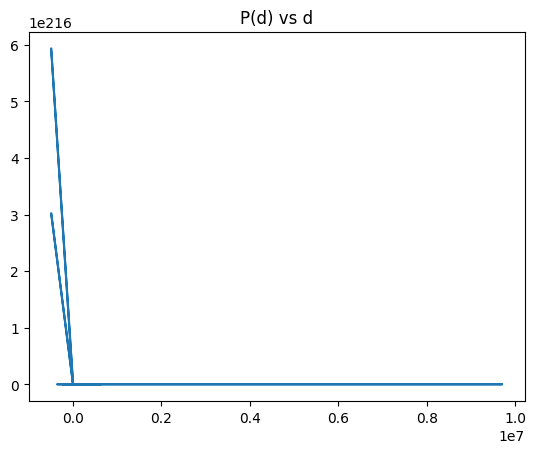

ValueError: Length of values (50) does not match length of index (1735)

In [50]:
def Prior(d):
    L = 1000
    return (1/L**3)*d**2*np.exp(-d/L)

def likelihood(w, sigma, d):
    return (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-0.5*(w - 1/d)**2/(2*sigma**2))

parallax_distrib = np.linspace(df["parallax"] - df["parallax_error"] , df["parallax"] - df["parallax_error"], 50)
print(parallax_distrib)
distance = 1000.0/parallax_distrib

plt.plot(distance[0], Prior(distance)[0])
plt.title('P(d) vs d')
plt.show()

plt.scatter(distance, likelihood(df["parallax"], df["parallax_error"], distance))
plt.title('P(w/d)')
plt.show()

plt.scatter(distance, likelihood(df["parallax"], df["parallax_error"], distance)*Prior(distance))
plt.title('P(d/w)')
plt.show()


In [ ]:
w = df["parallax"]
# Filter out only the positive x-values less than 8
#mask = (x > 0) & (x < 8)
#x_filtered = x[mask]
#P_d_filtered = P_d[mask]
